<a href="https://colab.research.google.com/github/MonishRaman/GAN-Project/blob/main/02_Data_Preparation_and_Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

In [16]:
geo = pd.read_csv("data/raw/GSE332947.csv")

print("="*60)
print("GEO DATASET LOADED")
print("="*60)

print("Shape :", geo.shape)

display(geo.head())

GEO DATASET LOADED
Shape : (51131, 36)


,Unnamed: 0,AUT138_01,AUT14_01,AUT143_01,AUT144_01,AUT145_01,AUT145_03,AUT147_01,AUT15_01,AUT180_01,...,AUT309_01,AUT311_01,AUT13_01,AUT191_01,AUT195_01,AUT201_01,AUT217_01b,AUT233_01,AUT261_01,AUT297_01
0,5S_rRNA,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7SK,136,173,93,76,28,100,90,187,22,...,29,27,71,119,118,72,96,106,98,53
2,A1BG,138,70,127,67,53,95,73,186,35,...,19,0,178,288,267,214,192,186,276,357
3,A1CF,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,A2LD1,44,47,50,21,5,13,4,46,1,...,10,0,129,33,157,120,78,31,200,216


In [17]:
geo.rename(columns={geo.columns[0]:"Gene"}, inplace=True)

print(geo.columns[:5])

Index(['Gene', 'AUT138_01', 'AUT14_01', 'AUT143_01', 'AUT144_01'], dtype='object')


In [18]:
geo.set_index("Gene", inplace=True)

print("="*60)
print("Gene column converted into Index")
print("="*60)

display(geo.head())

Gene column converted into Index


,AUT138_01,AUT14_01,AUT143_01,AUT144_01,AUT145_01,AUT145_03,AUT147_01,AUT15_01,AUT180_01,AUT182_01,...,AUT309_01,AUT311_01,AUT13_01,AUT191_01,AUT195_01,AUT201_01,AUT217_01b,AUT233_01,AUT261_01,AUT297_01
Gene,,,,,,,,,,,,,,,,,,,,,
5S_rRNA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7SK,136,173,93,76,28,100,90,187,22,84,...,29,27,71,119,118,72,96,106,98,53
A1BG,138,70,127,67,53,95,73,186,35,83,...,19,0,178,288,267,214,192,186,276,357
A1CF,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
A2LD1,44,47,50,21,5,13,4,46,1,38,...,10,0,129,33,157,120,78,31,200,216


In [19]:
geo_t = geo.T

print("="*60)
print("DATASET TRANSPOSED")
print("="*60)

print("Shape :", geo_t.shape)

display(geo_t.head())

DATASET TRANSPOSED
Shape : (35, 51131)


Gene,5S_rRNA,7SK,A1BG,A1CF,A2LD1,A2M,A2ML1,A2ML1-AS1,A2ML1-AS2,A2MP1,...,snoZ178,snoZ185,snoZ247,snoZ278,snoZ40,snoZ5,snoZ6,snosnR60_Z15,snosnR66,yR211F11.2
AUT138_01,0,136,138,0,44,27,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
AUT14_01,0,173,70,0,47,30,0,0,1,13,...,0,0,0,0,0,0,0,0,0,4
AUT143_01,0,93,127,0,50,25,2,0,0,3,...,0,0,0,0,0,0,0,0,0,0
AUT144_01,0,76,67,0,21,9,0,0,0,10,...,0,0,0,0,0,0,0,0,0,0
AUT145_01,0,28,53,0,5,2,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
print("="*60)
print("DATA VALIDATION")
print("="*60)

print("Missing Values :", geo_t.isnull().sum().sum())

print("Duplicate Samples :", geo_t.index.duplicated().sum())

print("Duplicate Genes :", geo_t.columns.duplicated().sum())

DATA VALIDATION
Missing Values : 0
Duplicate Samples : 0
Duplicate Genes : 0


In [21]:
geo_t.to_csv("data/processed/GEO_Transposed.csv")

print("Saved Successfully")

Saved Successfully


In [22]:
print("="*60)
print("RAW DATA STATISTICS")
print("="*60)

print("Minimum :", geo_t.min().min())

print("Maximum :", geo_t.max().max())

print("Mean :", geo_t.values.mean())

print("Standard Deviation :", geo_t.values.std())

RAW DATA STATISTICS
Minimum : 0
Maximum : 6201447
Mean : 444.1800328009008
Standard Deviation : 12802.975927345124


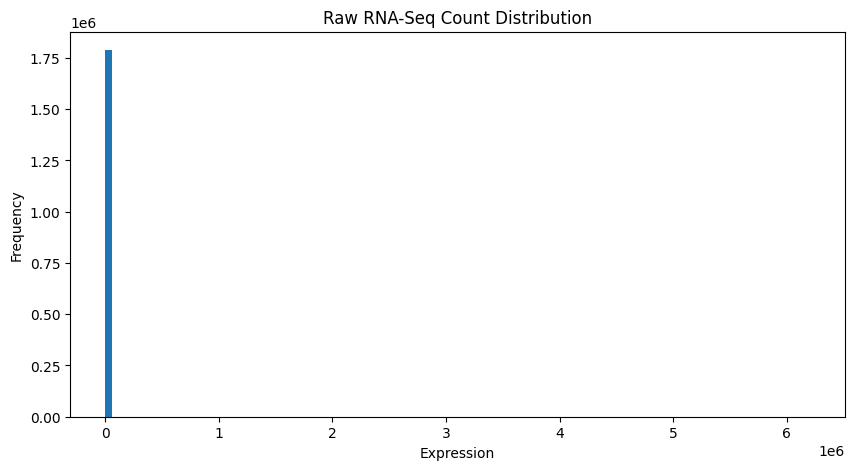

In [23]:
plt.figure(figsize=(10,5))

plt.hist(
    geo_t.values.flatten(),
    bins=100
)

plt.title("Raw RNA-Seq Count Distribution")

plt.xlabel("Expression")

plt.ylabel("Frequency")

plt.show()

In [24]:
geo_log = np.log2(geo_t + 1)

print("="*60)
print("LOG2 TRANSFORMATION COMPLETED")
print("="*60)

display(geo_log.head())

LOG2 TRANSFORMATION COMPLETED


Gene,5S_rRNA,7SK,A1BG,A1CF,A2LD1,A2M,A2ML1,A2ML1-AS1,A2ML1-AS2,A2MP1,...,snoZ178,snoZ185,snoZ247,snoZ278,snoZ40,snoZ5,snoZ6,snosnR60_Z15,snosnR66,yR211F11.2
AUT138_01,0.0,7.098032,7.118941,0.0,5.491853,4.807355,0.000000,0.0,0.0,2.321928,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
AUT14_01,0.0,7.442943,6.149747,0.0,5.584963,4.954196,0.000000,0.0,1.0,3.807355,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.321928
AUT143_01,0.0,6.554589,7.000000,0.0,5.672425,4.700440,1.584963,0.0,0.0,2.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
AUT144_01,0.0,6.266787,6.087463,0.0,4.459432,3.321928,0.000000,0.0,0.0,3.459432,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
AUT145_01,0.0,4.857981,5.754888,0.0,2.584963,1.584963,1.584963,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


In [25]:
print("="*60)
print("LOG2 DATA STATISTICS")
print("="*60)

print("Minimum :", geo_log.min().min())

print("Maximum :", geo_log.max().max())

print("Mean :", geo_log.values.mean())

print("Standard Deviation :", geo_log.values.std())

LOG2 DATA STATISTICS
Minimum : 0.0
Maximum : 22.564173684583892
Mean : 2.4964443559613465
Standard Deviation : 3.7822466826941903


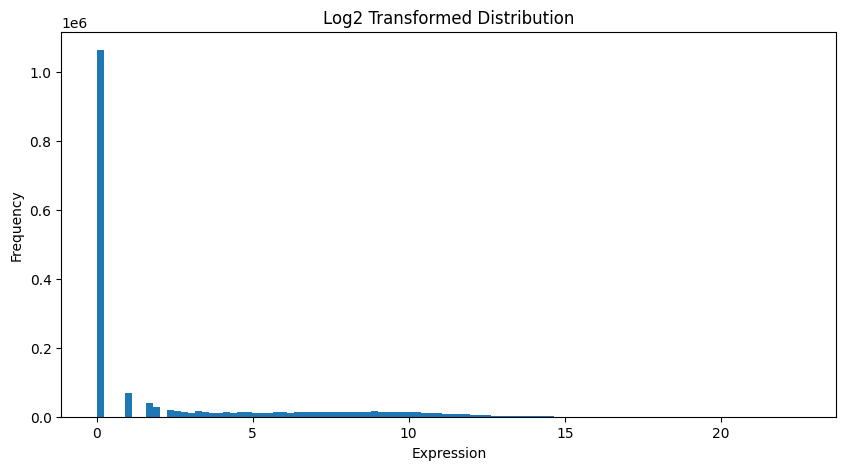

In [26]:
plt.figure(figsize=(10,5))

plt.hist(
    geo_log.values.flatten(),
    bins=100
)

plt.title("Log2 Transformed Distribution")

plt.xlabel("Expression")

plt.ylabel("Frequency")

plt.show()

In [27]:
scaler = StandardScaler()

geo_scaled = pd.DataFrame(
    scaler.fit_transform(geo_log),
    index=geo_log.index,
    columns=geo_log.columns
)

print("="*60)
print("Z-SCORE NORMALIZATION COMPLETED")
print("="*60)

display(geo_scaled.head())

Z-SCORE NORMALIZATION COMPLETED


Gene,5S_rRNA,7SK,A1BG,A1CF,A2LD1,A2M,A2ML1,A2ML1-AS1,A2ML1-AS2,A2MP1,...,snoZ178,snoZ185,snoZ247,snoZ278,snoZ40,snoZ5,snoZ6,snosnR60_Z15,snosnR66,yR211F11.2
AUT138_01,0.0,0.742690,0.469703,-0.171499,0.431499,0.697446,-0.593576,-0.171499,-0.535528,0.212476,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.227796
AUT14_01,0.0,1.100026,-0.158349,-0.171499,0.481138,0.795095,-0.593576,-0.171499,0.841180,1.231573,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.344983
AUT143_01,0.0,0.179672,0.392627,-0.171499,0.527767,0.626348,1.590430,-0.171499,-0.535528,-0.008387,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.227796
AUT144_01,0.0,-0.118497,-0.198710,-0.171499,-0.118917,-0.290357,-0.593576,-0.171499,-0.535528,0.992876,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.227796
AUT145_01,0.0,-1.578049,-0.414224,-0.171499,-1.118254,-1.445432,1.590430,-0.171499,-0.535528,-1.380514,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.227796


In [28]:
print("="*60)
print("AFTER NORMALIZATION")
print("="*60)

print("Mean :", np.mean(geo_scaled.values))

print("Std :", np.std(geo_scaled.values))

AFTER NORMALIZATION
Mean : -5.437905050036926e-17
Std : 0.7901874201010789


In [29]:
selector = VarianceThreshold(threshold=0.01)

geo_selected = selector.fit_transform(geo_scaled)

selected_columns = geo_scaled.columns[selector.get_support()]

geo_selected = pd.DataFrame(
    geo_selected,
    index=geo_scaled.index,
    columns=selected_columns
)

print("="*60)
print("VARIANCE THRESHOLD COMPLETED")
print("="*60)

print("Original Features :", geo_scaled.shape[1])

print("Selected Features :", geo_selected.shape[1])

VARIANCE THRESHOLD COMPLETED
Original Features : 51131
Selected Features : 31926


In [30]:
geo_selected.to_csv(
    "data/processed/GEO_Preprocessed.csv"
)

print("="*60)
print("PREPROCESSED DATASET SAVED")
print("="*60)

PREPROCESSED DATASET SAVED


In [31]:
print("="*70)
print("OBJECTIVE 1 - PHASE 3 COMPLETED")
print("="*70)

print("Original Dataset Shape :", geo.shape)

print("Transposed Dataset Shape :", geo_t.shape)

print("After Log2 Shape :", geo_log.shape)

print("After Z-score Shape :", geo_scaled.shape)

print("After Variance Threshold :", geo_selected.shape)

print("="*70)

OBJECTIVE 1 - PHASE 3 COMPLETED
Original Dataset Shape : (51131, 35)
Transposed Dataset Shape : (35, 51131)
After Log2 Shape : (35, 51131)
After Z-score Shape : (35, 51131)
After Variance Threshold : (35, 31926)
